<a href="https://colab.research.google.com/github/reneaps1/analisys-everpeak/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("\nCantidad de Valores nulos:\n")
print(users.isna().sum())
print('\nPorcion de valores nulos: \n')
print(users.isna().mean()*100)


Cantidad de Valores nulos:

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Porcion de valores nulos: 

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("\nCantidad de Valores nulos:\n")
print(usage.isna().sum())
print('\nPorcion de valores nulos: \n')
print(usage.isna().mean()*100)


Cantidad de Valores nulos:

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Porcion de valores nulos: 

id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


In [ ]:
#Para identificar cantidad de llamadas en df usage se realizara la segmentación de cuantas llamadas y mensajes de texto existen en dicha columna.


textos=usage['type']=='text'

print('Cantidad de texts:', textos.sum())

llamadas=usage['type']=='call'
print('Cnatidad de llamadas', llamadas.sum())

Cantidad de texts: 22092
Cnatidad de llamadas 17908


In [ ]:
usage[usage['type']=='text'].duration.value_counts() #esto se puede quitar

120.0    16
Name: duration, dtype: int64

Para users se identifica que hay nulos en la columna city, es el 11.72%, que corresponde a 469 valores. No representa un valor elevado por lo cual se podria ignorar.


Se identifica que hay valores nulos en las columnas:

0.125% en la columna date, son 50 datos.Es un porcentaje muy bajo, por lo cual sería posible **ignorar** los datos faltantes.  
55.19% en la columna duration. Es un porcentaje elevado, sin embargo es posible que se deba a que los mensajes no tienen duracion en tiempo.
44.74% en la columna lenght. Es un porcentaje elevado, sin embargo es posible que se deba a que las llamadas no tienen una longitud de texto.

Para definir el tratamiento de los NaN de duration y length se procedera a identificar si dichos valores corresponden exclusivamente a las llamadas y mensajes.


Se identifica que :

* 'duration' los 22076 NaN en la columna duration corresponden a la cantidad de textos. Es decir: Los 22076 NaN resultantes no representan un problema, ya que los textos no tienen una duración de tiempo. **Se pueden ignorar**
* 'lenght' los 17986  valores Nan fueron clasificados así ya que dicha cantidad no tiene una longitud de caracteres ya que esa cantidad de NaN corresponde a registros de textos enviados. **Se pueden ignorar**

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no muestra sentinels o valores invalidos.
- La columna `age` muestra que hay sentinels ya que hay un minimo de edad de -999.

In [ ]:
# Exploracion de columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`no muestra que existan sentinels.
- Las columnas duration y length tampoco muestran sentinels.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print('\nCol:', col, "\n", users[col].describe())


Col: city 
 count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

Col: plan 
 count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object


- La columna `city` muestra que el principal pais de los usuarios es Bogotá y que tiene 808 usuarios. Se identifica que en el data set hay solo 7 ciudades registradas.
- La columna `plan` muestra que el plan principal es el básico, con 2595, y qué solo hay dos tipos de plantes

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` indica que los textos son el uso más comun, con una frecuencia de 22092. El resto corresponde a llamadas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, se identifica que hay años futuros: 2026

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, los años se encuentran dentro del periodo a analizar.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

-----
Puedo verificar que las fechas de 'da'te del dataset usage, se encuentran en orden. Sin embargo, es necesario anular los años del dataset de users, ya que se salen del rango de análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana =users['age'].median()
users['age'] =  users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city

users['city']=users['city'].replace('?',np.nan)
users['city'].value_counts() # Verificar cambios

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date']=np.where(users['reg_date']>'2025-01-01',pd.NaT, users['reg_date'])
users['reg_date']=pd.to_datetime(users['reg_date'],errors='coerce')
# Verificar cambios
users['reg_date'].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration


llamadas=usage['type']=='call'
print('Cnatidad de llamadas', llamadas.sum())


print('Cantidad de nulos: ',usage['length'].isna().sum())

Cnatidad de llamadas 17908
Cantidad de nulos:  17896


In [ ]:
# Verificación MAR en usage (Missing At Random) para length

textos=usage['type']=='text'
print('Cantidad de texts:', textos.sum())


print('Cantidad de nulos: ',usage['type'].isna().sum())


Cantidad de texts: 22092
Cantidad de nulos:  0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los NaN de duration y lenght son tipo MNAR por lo siguiente:
* Los datos NaN en duration, corresponden a los mensajes de texto, éstos no tienen una duración en minutos.
* Los datos Nan en lenght, corresponden a las llamadas, éstas no tienen una longitud de caracteres.
* Se detectaron algunos casos atípicos donde registros de tipo "call" contienen valores en la variable length, lo cual no es consistente con la naturaleza de los datos. Esto sugiere posibles inconsistencias o errores de registro, aunque no afectan significativamente la conclusión general sobre los valores faltantes.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    {
        'is_text':'sum',
        'is_call':'sum',
        'length':'sum'
    }
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,length
0,10000,7,3,258.0
1,10001,5,10,226.0
2,10002,5,2,225.0


In [ ]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text':'cant_mensajes',
    'is_call':'cant_llamadas',
    'length':'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,258.0
1,10001,5,10,226.0
2,10002,5,2,225.0


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg,on=['user_id'],how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,258.0
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.122250
std,1154.844867,17.690408
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

Se identifica que el tipo de plan con mayor numero de usuarios es el plan básico con 64.8%.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

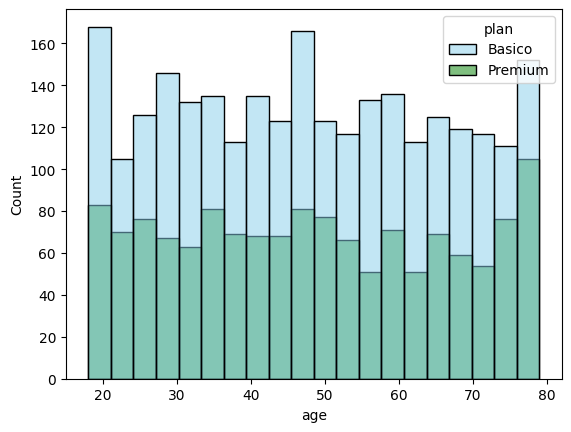

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=20,
    palette=['skyblue','green'],
    edgecolor='black'
)
plt.show()

💡Insights:
- Distribución ...

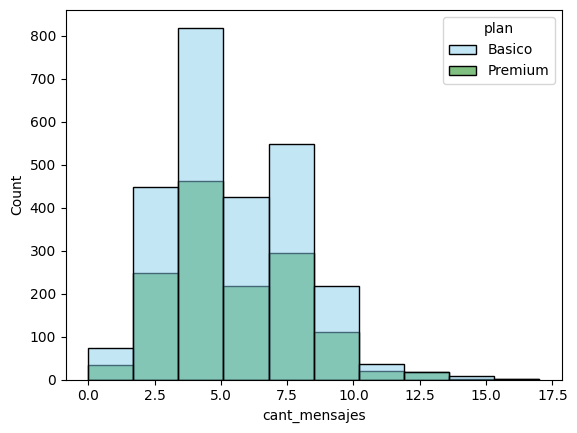

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=10,
    palette=['skyblue','green'],
    edgecolor='black'
)
plt.show()


💡Insights:
- ....

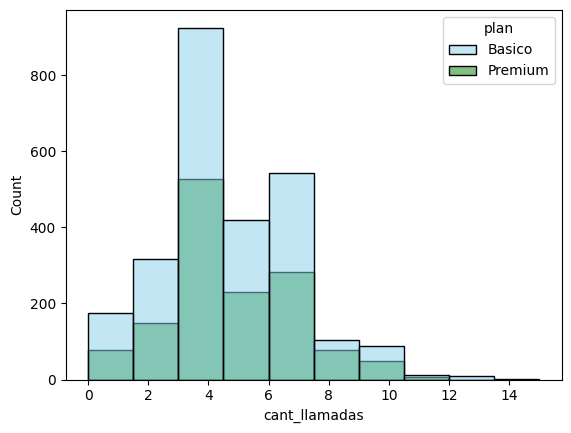

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=10,
    palette=['skyblue','green'],
    edgecolor='black'
)
plt.show()



💡Insights:
- Distribución ...

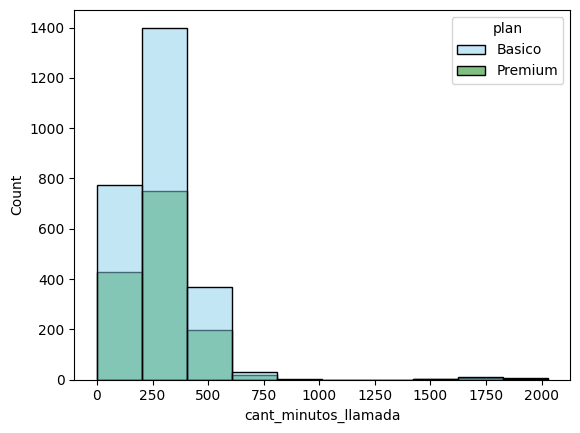

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=10,
    palette=['skyblue','green'],
    edgecolor='black'
)
plt.show()


💡Insights:
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

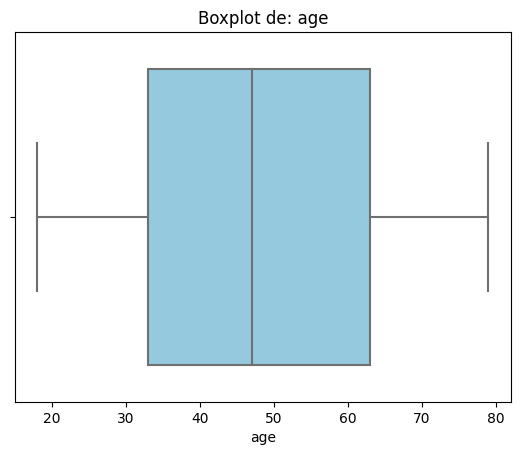

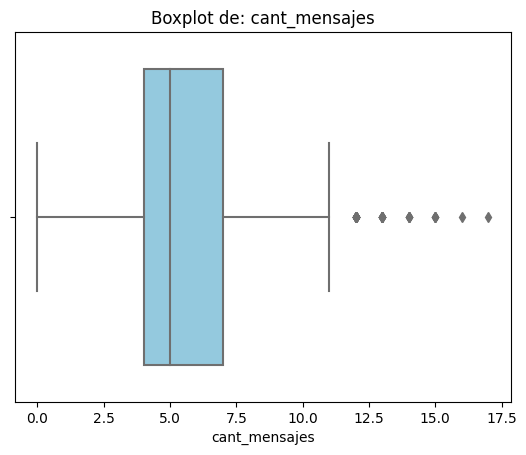

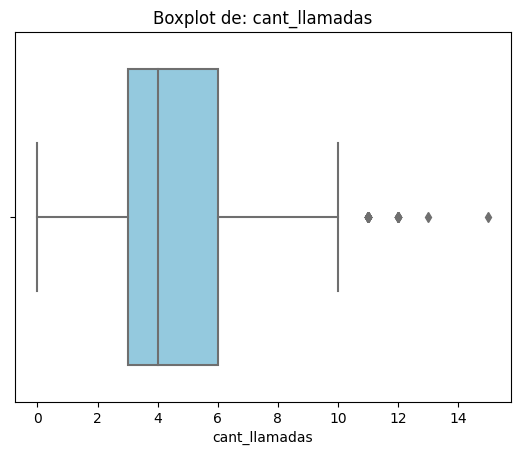

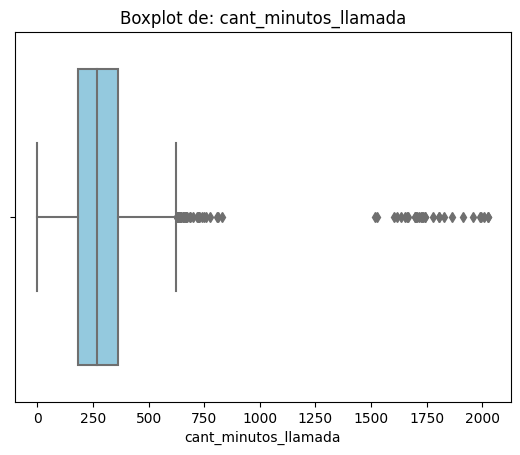

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(
        x=user_profile[col],
        color='skyblue'
    )
    plt.title('Boxplot de: '+ col)
    plt.show()


💡Insights:
- Age: no presenta outliers
- cant_mensajes: Presenta outliers
- cant_llamadas: Presenta outliers
- cant_minutos_llamada: Presenta outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    q1=user_profile[col].quantile(.25)
    q3=user_profile[col].quantile(.75)
    iqr=q3-q1
    upper=q3+1.5*iqr
    lower=q1-1.5*iqr
    print('El IQR de',col,' es: ', iqr, 'Limite upper: ',upper, 'Limite lower: ',lower)

El IQR de age  es:  30.0 Limite upper:  108.0 Limite lower:  -12.0
El IQR de cant_mensajes  es:  3.0 Limite upper:  11.5 Limite lower:  -0.5
El IQR de cant_llamadas  es:  3.0 Limite upper:  10.5 Limite lower:  -1.5
El IQR de cant_minutos_llamada  es:  177.0 Limite upper:  626.5 Limite lower:  -81.5


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,288.128032
std,17.690408,2.358416,2.144238,180.906841
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,184.000000
50%,47.000000,5.000000,4.000000,268.000000
75%,63.000000,7.000000,6.000000,361.000000
max,79.000000,17.000000,15.000000,2028.000000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
user_profile['grupo_uso'] = np.where(
    user_profile['cant_llamadas'].isna() | user_profile['cant_mensajes'].isna(),
    'Sin datos',
    np.where(
        (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
        'Bajo uso',
        np.where(
            (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
            'Uso medio',
            'Alto uso'
        )
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,258.0,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad']=np.where(
    user_profile['age'].isna(),
    'Sin datos',
    np.where(
        user_profile['age']<30,
        'Joven',
        np.where(
            user_profile['age']<60,
            'Adulto','Adulto Mayor'
        )
    )

)

In [ ]:
# verificar cambios
user_profile.head()
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

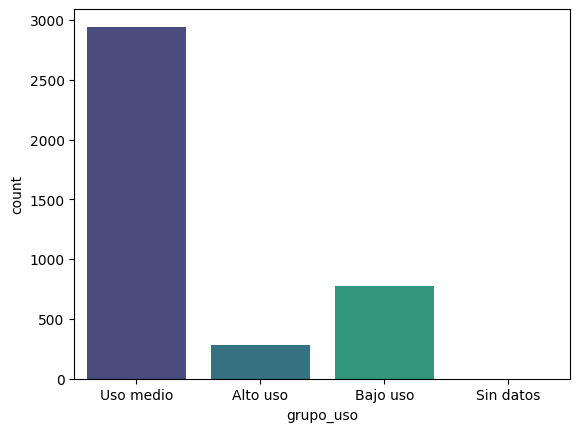

In [ ]:

# Visualización de los segmentos por uso


sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette='viridis')

plt.show()



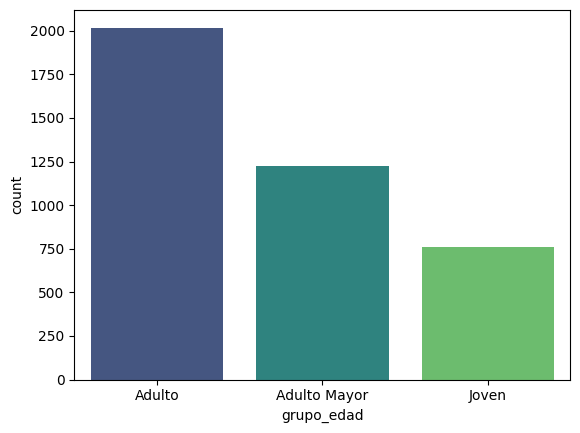

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette='viridis')


plt.show()


Perfecto 🔥 — aquí te lo dejo listo para copiar y pegar, manteniendo TU estilo pero mejor estructurado, sin redundancias y respondiendo todo claramente:

## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 Objetivo: Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

Preguntas a responder:

¿Qué problemas tenían originalmente los datos? ¿Qué porcentaje, o cantidad de filas, representaban?


    - Se identificaron valores nulos en columnas como city (~11.7% de los datos).
    - También se encontraron valores faltantes en variables de uso como llamadas y mensajes.
    - Se detectaron fechas inconsistentes y algunos valores atípicos en variables numéricas.


¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

    -La mayoría de los usuarios se concentra en rangos de edad intermedios.
    -No se observan diferencias extremadamente marcadas entre grupos, aunque los usuarios adultos presentan ligeramente mayor actividad.
    -En cuanto al nivel de uso, la mayor parte de los usuarios pertenece al grupo de uso medio.
    -El grupo de alto uso es menor en cantidad, pero representa a los usuarios más activos.
    -Se identificó un grupo de usuarios "Sin datos", lo cual indica información incompleta.
¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

    - Los usuarios de alto uso son los más valiosos, ya que generan mayor consumo de servicios.
    - Los usuarios de uso medio representan una oportunidad importante para incrementar ingresos mediante estrategias de conversión.
¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

    -Se identificaron valores atípicos en variables como minutos de llamada y cantidad de interacciones.
    -Estos casos pueden representar usuarios intensivos más que errores, lo que sugiere la necesidad de planes específicos para este tipo de clientes.
¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes?

    - Diseñar planes específicos para usuarios de alto consumo.
    - Implementar estrategias para convertir usuarios de uso medio en alto uso.
    - Analizar a los usuarios de bajo uso para aumentar su engagement.
    - Mejorar la calidad de los datos, especialmente en variables clave.

✍️ Análisis ejecutivo

- Los usuarios de uso medio representan una oportunidad clara para aumentar ingresos.
- Los usuarios de alto uso son los más valiosos debido a su nivel de consumo.
- La mayoría de los usuarios se concentra en edades intermedias, sin diferencias extremadamente marcadas.
- La existencia de usuarios sin datos puede afectar la toma de decisiones si no se maneja adecuadamente.
- Se identificaron usuarios con patrones de uso intensivo que podrían beneficiarse de planes especializados.

### 7.1. Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Se identificaron valores nulos en columnas como *city* (~11.7% de los datos).
- También se encontraron valores faltantes en variables de uso como llamadas y mensajes, además de algunas inconsistencias en fechas y valores atípicos.

---

🔍 **Segmentos por Edad**

- La mayoría de los usuarios se concentra en rangos de edad intermedios.
- No se observan diferencias muy marcadas entre grupos, aunque los usuarios adultos muestran ligeramente mayor actividad.

---

📊 **Segmentos por Nivel de Uso**

- La mayor parte de los usuarios pertenece al grupo de uso medio.
- El grupo de alto uso es menor en cantidad, pero representa a los usuarios más activos, además de existir un grupo "Sin datos" por información incompleta.

---

➡️ **Esto sugiere que ...**

- Los usuarios de uso medio representan una oportunidad clara para incrementar ingresos.
- Los usuarios de alto uso son los más valiosos debido a su nivel de consumo.
- La presencia de usuarios sin datos puede afectar el análisis si no se maneja adecuadamente.
- La presencia de usuarios con uso intensivo sugiere la necesidad de planes más flexibles o especializados.

---

💡 **Recomendaciones**

- Diseñar planes específicos para usuarios de alto consumo.
- Implementar estrategias para convertir usuarios de uso medio en alto uso.
- Analizar a los usuarios de bajo uso para aumentar su engagement.
- Mejorar la calidad de los datos, especialmente en variables clave.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`